# Phase 1 vs. Phase 1 Volcano Plots

using results from [deseq_p1.v.p1.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/deseq_p1.v.p1.ipynb) to generate publication-formatted volcano plots

## 0. load libraries

In [16]:
library(tidyverse) # for ggplot and dplyr
library(cowplot) # for combining plots

## 1. load CSVs and write DEGs csv

In [17]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq',
    pattern = '\\.csv$',
    full.names = TRUE
    )

# remove vst file
files <- files[basename(files) != "p1_vst.csv"]

head(files)

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.both_v_cont.csv"
[2] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.hyp_v_both.csv" 
[3] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.hyp_v_cont.csv" 
[4] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.hyp_v_warm.csv" 
[5] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.warm_v_both.csv"
[6] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.warm_v_cont.csv"

The order of oyster treatment is intential - the oyster listed second is the 'baseline' from DESeq. In other words, If the file name is both_v_cont.csv, then the LFC values are for B in relation to C (a +lfc = more expression in B, a -lfc = more expression in C)

I want to read in a csv, assign directionality to DEGs (or mark genes as not significant)

In [71]:
deg_list <- lapply(files, function(f) {

  df <- read.csv(f)

  # remove extension
  name <- tools::file_path_sans_ext(basename(f))

  # remove prefix up to first dot
  name2 <- sub("^.*\\.", "", name)

  # split on _v_
  groups <- strsplit(name2, "_v_")[[1]]

  g1 <- substr(toupper(groups[1]), 1, 1)
  g2 <- substr(toupper(groups[2]), 1, 1)

  # comparison label
  df$pair <- paste(g2, "vs.", g1)

  # Default everything to NS
  df$DEG_group <- "NS"

  # Significant and higher in g1
  df$DEG_group[
    !is.na(df$padj) &
    !is.na(df$log2FoldChange) &
    df$padj < 0.05 &
    df$log2FoldChange > 1
  ] <- g1

  # Significant and higher in g2
  df$DEG_group[
    !is.na(df$padj) &
    !is.na(df$log2FoldChange) &
    df$padj < 0.05 &
    df$log2FoldChange < -1
  ] <- g2

  df
})

In [72]:
# assigning names to deg_list to be able to call downstream
file_names <- tools::file_path_sans_ext(basename(files))

groups <- strsplit(
  sub("^.*\\.", "", file_names),
  "_v_"
)

names(deg_list) <- sapply(groups, function(x) {
  paste0(
    substr(x[1], 1, 1),
    "_",
    substr(x[2], 1, 1)
  ) |> tolower()
})

In [73]:
names(deg_list)

head(deg_list$b_c)

[1] "b_c" "h_b" "h_c" "h_w" "w_b" "w_c"

,X,Gene,log2FoldChange,lfcSE,pvalue,padj,pair,DEG_group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,LOC144621260,2772.7662,0.0006761802,0.02228363,7.787130e-01,0.996753837,C vs. B,NS
2,LOC144621269,6797.3814,0.0043087230,0.10996986,5.813767e-01,0.992028790,C vs. B,NS
3,LOC111120925,191.4430,-4.8964652929,1.40924743,8.354541e-06,0.003582926,C vs. B,C
4,LOC144621283,932.0540,0.0011782772,0.02371156,6.197830e-01,0.992275338,C vs. B,NS
5,LOC144621276,12350.8892,0.0012266111,0.02480930,5.976185e-01,0.992028790,C vs. B,NS
6,LOC111115920,213.3386,0.0676324761,0.25037815,6.160028e-03,0.234877458,C vs. B,NS


writing out *only* DEGs for downstream analysis

In [74]:
out_dir <- "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/DEGs/"  

for (nm in names(deg_list)) {

  df <- deg_list[[nm]]

  deg_df <- df[!is.na(df$DEG_group) & df$DEG_group != "NS", ]

  write.csv(
    deg_df,
    file = file.path(out_dir, paste0("DEG_", nm, ".csv")),
    row.names = FALSE
  )
}


In [97]:
all_comps <- rbind(deg_list$w_c, deg_list$h_c, deg_list$b_c, deg_list$h_b, deg_list$h_w, deg_list$w_b)
head(all_comps)
unique(all_comps$DEG_group)

,X,Gene,log2FoldChange,lfcSE,pvalue,padj,pair,DEG_group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,LOC144621260,2772.7662,0.003885262,0.05316204,0.786212340,0.9854482,C vs. W,NS
2,LOC144621269,6797.3814,0.003801927,0.10469548,0.661212658,0.9788519,C vs. W,NS
3,LOC111120925,191.4430,-0.156646478,0.64822786,0.009549292,0.3809633,C vs. W,NS
4,LOC144621283,932.0540,0.006911177,0.05720338,0.633130467,0.9746109,C vs. W,NS
5,LOC144621276,12350.8892,0.014835592,0.06730795,0.340631041,0.9081505,C vs. W,NS
6,LOC111115920,213.3386,-0.003229042,0.06581014,0.801546841,0.9875021,C vs. W,NS


[1] "NS" "C"  "W"  "H"  "B"

## 2. ggplot

### comparisons vs. control

In [75]:
cont_only <- rbind(deg_list$w_c, deg_list$h_c, deg_list$b_c)

head(cont_only)
tail(cont_only)

,X,Gene,log2FoldChange,lfcSE,pvalue,padj,pair,DEG_group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,LOC144621260,2772.7662,0.003885262,0.05316204,0.786212340,0.9854482,C vs. W,NS
2,LOC144621269,6797.3814,0.003801927,0.10469548,0.661212658,0.9788519,C vs. W,NS
3,LOC111120925,191.4430,-0.156646478,0.64822786,0.009549292,0.3809633,C vs. W,NS
4,LOC144621283,932.0540,0.006911177,0.05720338,0.633130467,0.9746109,C vs. W,NS
5,LOC144621276,12350.8892,0.014835592,0.06730795,0.340631041,0.9081505,C vs. W,NS
6,LOC111115920,213.3386,-0.003229042,0.06581014,0.801546841,0.9875021,C vs. W,NS


,X,Gene,log2FoldChange,lfcSE,pvalue,padj,pair,DEG_group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
75583,LOC111111213,13111.89387,-0.0012985046,0.02501970,0.57743176,0.9919909,C vs. B,NS
75584,LOC111114497,125.35335,0.0483757066,0.25213564,0.01850096,0.4277669,C vs. B,NS
75585,LOC111114498,4151.99515,0.0007094658,0.02497408,0.74985563,0.9967538,C vs. B,NS
75586,LOC111112304,1812.87938,0.0040156704,0.03565835,0.17481838,0.8762277,C vs. B,NS
75587,LOC144621306,26.81000,0.0107427160,0.18864462,0.44480817,0.9770931,C vs. B,NS
75588,LOC144621888,40.24362,-0.0003526433,0.06284152,0.93567260,0.9977638,C vs. B,NS


Warning message:
“Removed 1275 rows containing missing values or values outside the scale range
(`geom_point()`).”


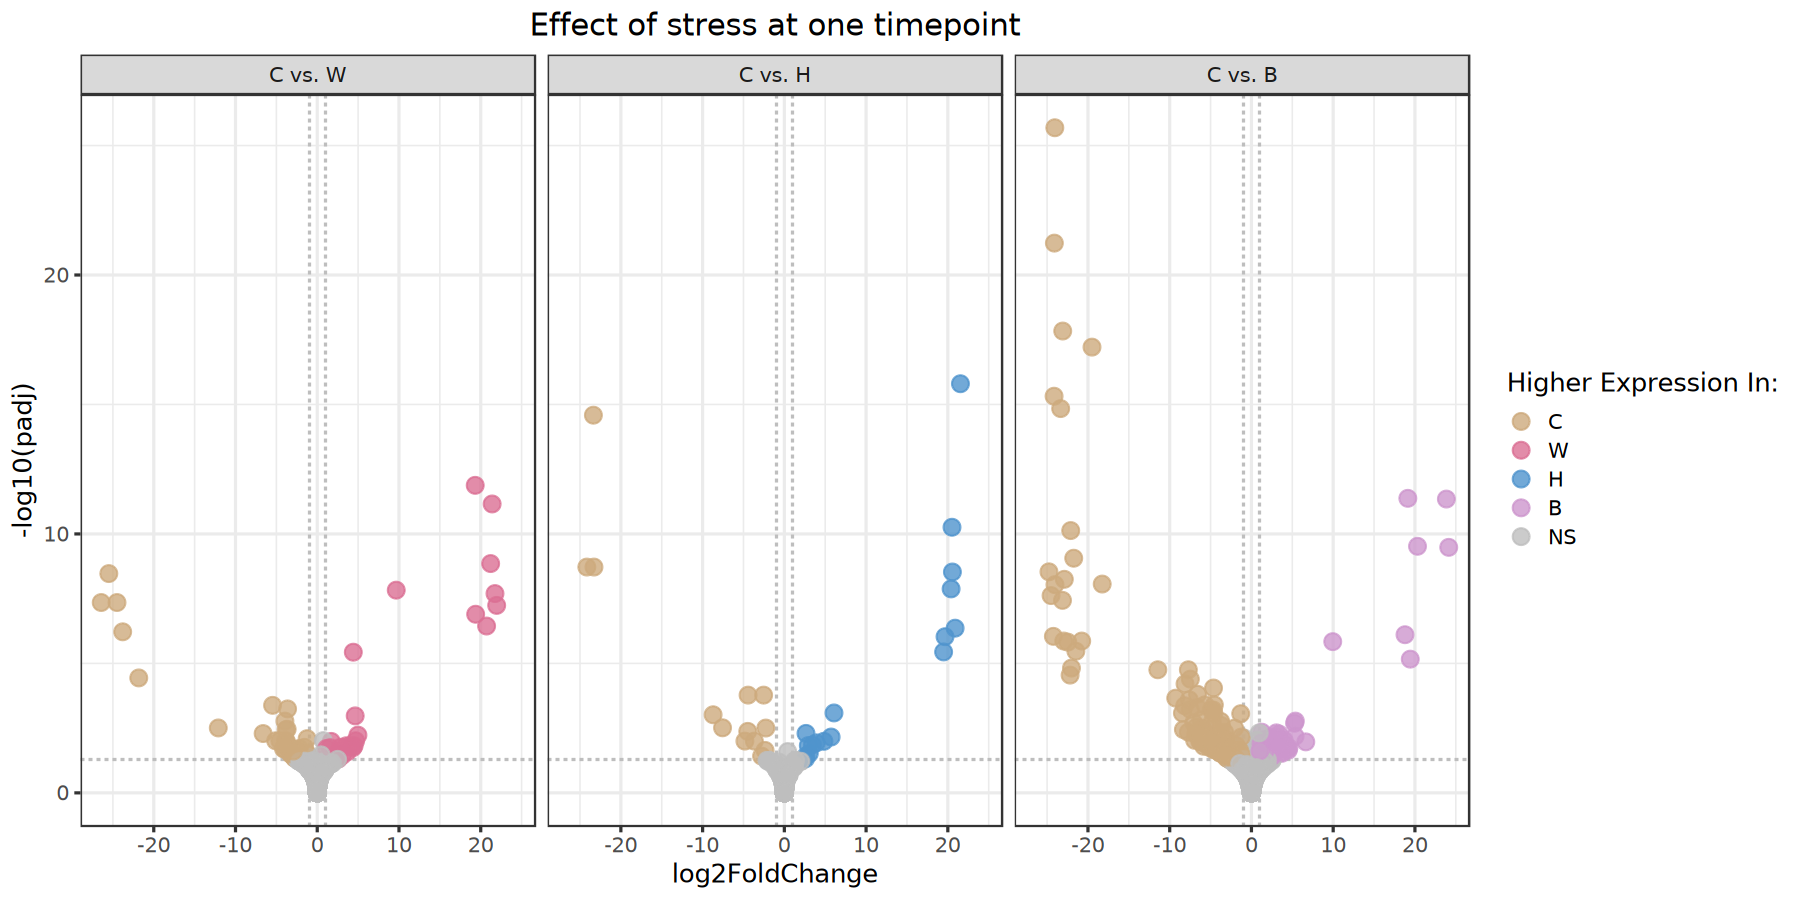

In [76]:
options(repr.plot.width=15, repr.plot.height=7.5)

# Specify the order for plots to follow Sophie's order
cont_only$pair <- factor(cont_only$pair, levels = c("C vs. W", "C vs. H", "C vs. B"))

# change order of legend
cont_only$DEG_group <- factor(
  cont_only$DEG_group,
  levels = c("NS", "B", "H", "W", "C")
)

# plot
cont_only.plot <- ggplot(data = cont_only,
                     aes(x = log2FoldChange,
                         y = -log10(padj),
                         col = DEG_group)) +
# fold change threshold line
geom_vline(xintercept = c(-1, 1), 
           col = "gray",
           linetype = "dashed") +
# adjusted p-value line
geom_hline(yintercept = -log10(0.05),
           col = "gray",
           linetype = "dashed") +
scale_color_manual(values = c("H" = "steelblue3", "W" = "palevioletred", "C" = "burlywood3", "B" = "plum3", "NS" = "grey")) +
facet_wrap(~pair) +
geom_point(size=4, alpha = 0.8) +
theme_bw(base_size = 15) +
theme(plot.title = element_text(hjust=.5)) + 
labs(col = 'Higher Expression In:',
    title = 'Effect of stress at one timepoint') +
guides(col = guide_legend(reverse = TRUE))

cont_only.plot

In [77]:
#ggsave('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/plots/vs.control_volcano.pdf', cont_only.plot, width=15, height=7.5)

### other comparisons

In [78]:
other_comp <- rbind(deg_list$w_b, deg_list$h_b, deg_list$h_w)

head(other_comp)
tail(other_comp)

,X,Gene,log2FoldChange,lfcSE,pvalue,padj,pair,DEG_group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,LOC144621260,2772.7662,-0.0009737601,0.09401341,0.982154041,0.9982963,B vs. W,NS
2,LOC144621269,6797.3814,-0.0016584778,0.12417123,0.893775096,0.9880558,B vs. W,NS
3,LOC111120925,191.4430,0.0536837020,0.32931035,0.044830068,0.5503345,B vs. W,NS
4,LOC144621283,932.0540,-0.0016897572,0.09607764,0.967320878,0.9973136,B vs. W,NS
5,LOC144621276,12350.8892,0.0147940640,0.09809364,0.703389889,0.9578470,B vs. W,NS
6,LOC111115920,213.3386,-0.1362649242,0.23510683,0.002907235,0.2069981,B vs. W,NS


,X,Gene,log2FoldChange,lfcSE,pvalue,padj,pair,DEG_group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
75583,LOC111111213,13111.89387,-0.064120394,0.1328129,0.37775718,0.8069323,W vs. H,NS
75584,LOC111114497,125.35335,-0.062759045,0.1682506,0.22386763,0.7021580,W vs. H,NS
75585,LOC111114498,4151.99515,0.106492161,0.1439715,0.14208590,0.6186540,W vs. H,NS
75586,LOC111112304,1812.87938,0.043176005,0.1325888,0.54719786,0.8814285,W vs. H,NS
75587,LOC144621306,26.81000,0.007972453,0.1900069,0.71169478,0.9391329,W vs. H,NS
75588,LOC144621888,40.24362,-0.095304875,0.2732782,0.03018951,0.4117396,W vs. H,NS


Warning message:
“Removed 2737 rows containing missing values or values outside the scale range
(`geom_point()`).”


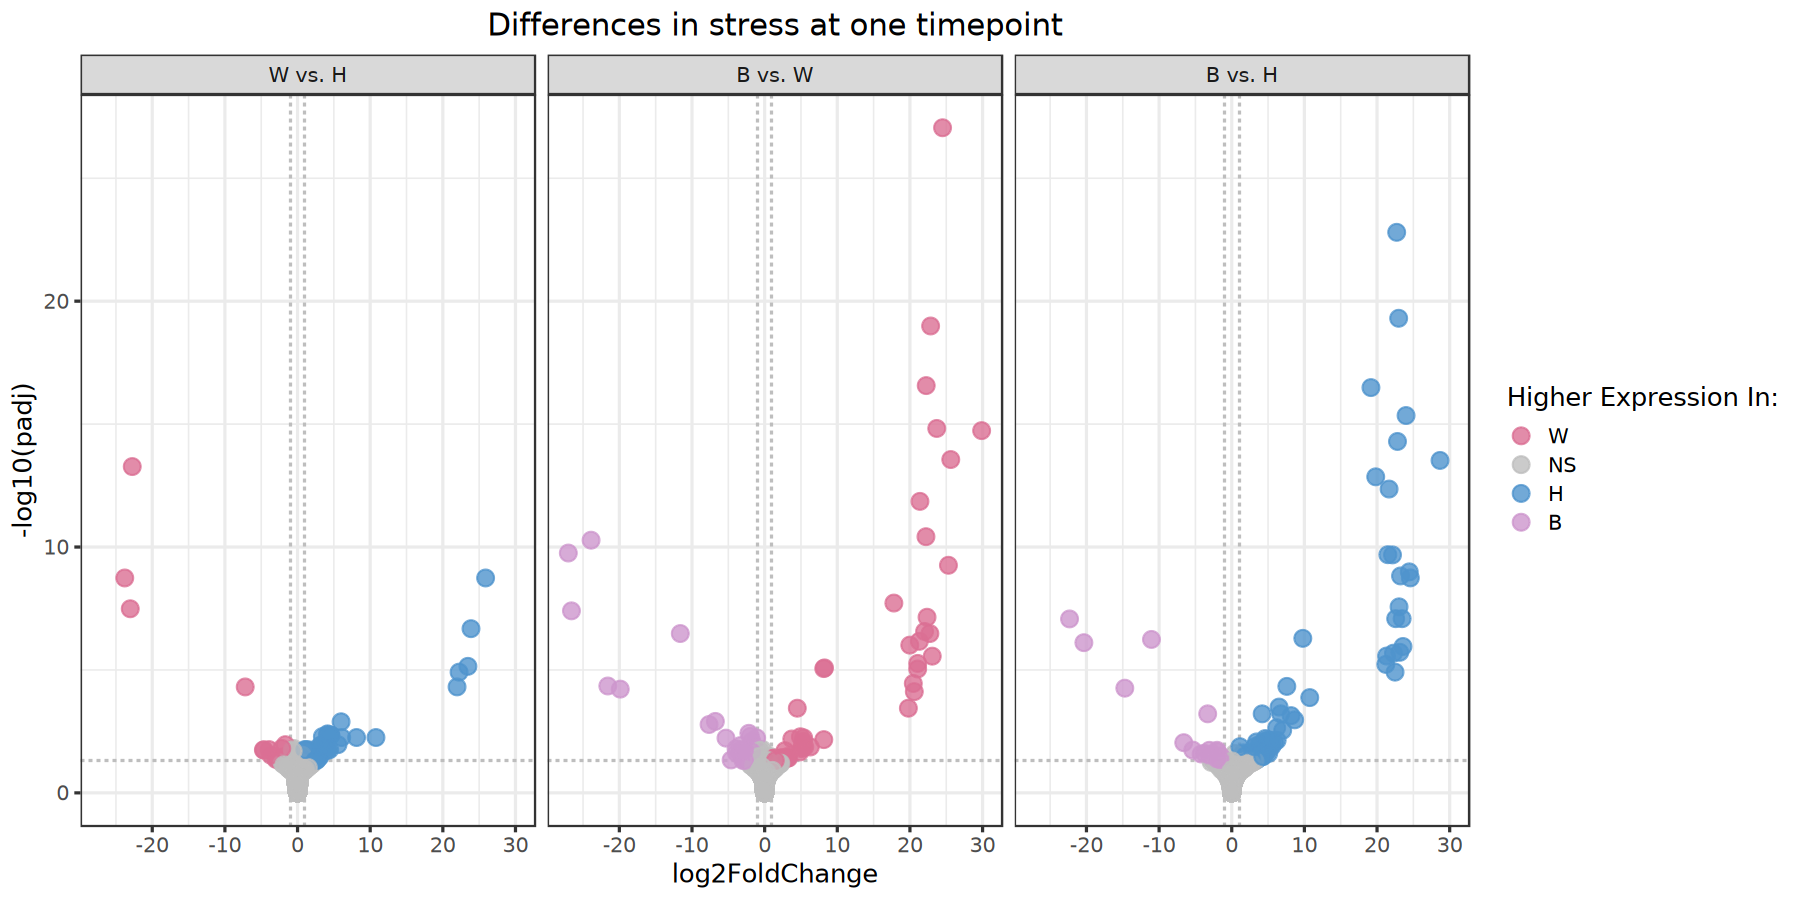

In [79]:
options(repr.plot.width=15, repr.plot.height=7.5)

# Specify the order for plots to follow Sophie's order
other_comp$pair <- factor(other_comp$pair, levels = c("W vs. H", "B vs. W", "B vs. H"))

# change order of legend
cont_only$DEG_group <- factor(
  cont_only$DEG_group,
  levels = c("NS", "B", "H", "W")
)

# plot
other_comp.plot <- ggplot(data = other_comp,
                     aes(x = log2FoldChange,
                         y = -log10(padj),
                         col = DEG_group)) +
# fold change threshold line
geom_vline(xintercept = c(-1, 1), 
           col = "gray",
           linetype = "dashed") +
# adjusted p-value line
geom_hline(yintercept = -log10(0.05),
           col = "gray",
           linetype = "dashed") +
scale_color_manual(values = c("H" = "steelblue3", "W" = "palevioletred", "B" = "plum3", "NS" = "grey")) +
facet_wrap(~pair) +
geom_point(size=4, alpha = 0.8) +
theme_bw(base_size = 15) +
theme(plot.title = element_text(hjust=.5)) + 
labs(col = 'Higher Expression In:',
    title = 'Differences in stress at one timepoint') +
guides(col = guide_legend(reverse = TRUE))

other_comp.plot

In [80]:
#ggsave('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/plots/vs.other_volcano.pdf', other_comp.plot, width=15, height=7.5)

### everything together

Warning message:
“Removed 4012 rows containing missing values or values outside the scale range
(`geom_point()`).”


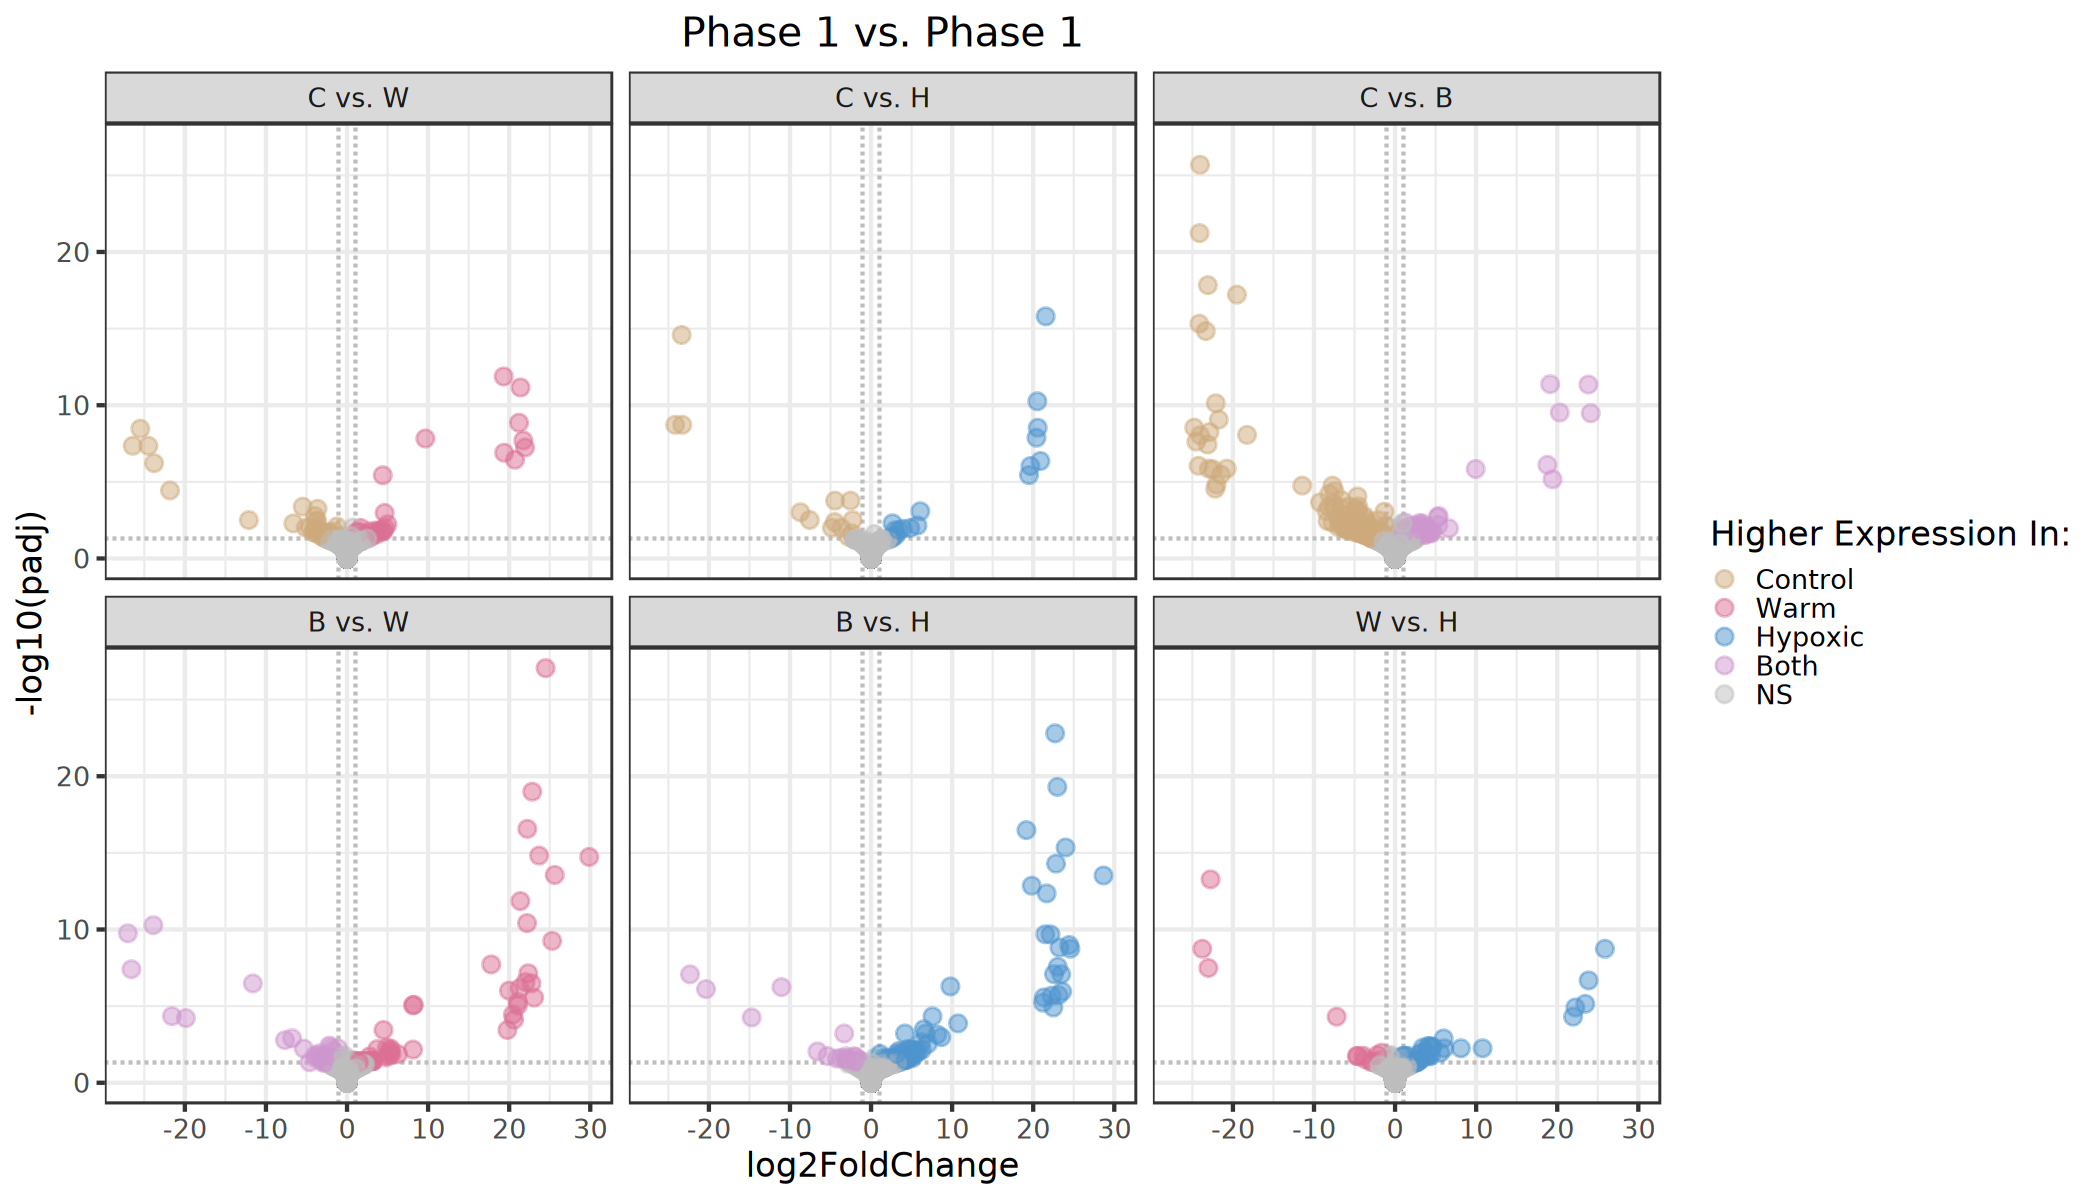

In [99]:
options(repr.plot.width=17.5, repr.plot.height=10)

# Specify the order for plots to follow Sophie's order
all_comps$pair <- factor(all_comps$pair, levels = c("C vs. W",
                                                    "C vs. H",
                                                    "C vs. B",
                                                    "B vs. W",
                                                    "B vs. H",
                                                   "W vs. H"))

# reorder appearance of treatments in legend
all_comps$DEG_group <- factor(all_comps$DEG_group, levels = c('C', 'W', 'H', 'B', 'NS'))


all_comp.plot <- ggplot(data = all_comps,
                     aes(x = log2FoldChange,
                         y = -log10(padj),
                         col = DEG_group)) +
# fold change threshold line
geom_vline(xintercept = c(-1, 1), 
           col = "gray",
           linetype = "dashed") +
# adjusted p-value line
geom_hline(yintercept = -log10(0.05),
           col = "gray",
           linetype = "dashed") +
scale_color_manual(values = c("C" = "burlywood3", "H" = "steelblue3", "W" = "palevioletred", "B" = "plum3", "NS" = "grey"), 
                  labels = c('Control', 'Warm', 'Hypoxic', 'Both', 'NS')) +
facet_wrap(~pair) +
geom_point(size=4, alpha = 0.5) +
theme_bw(base_size = 20) +
theme(plot.title = element_text(hjust=.5)) + 
labs(col = 'Higher Expression In:',
    title = 'Phase 1 vs. Phase 1') +
guides(col = guide_legend(reverse = FALSE))

all_comp.plot

In [84]:
#ggsave('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/plots/all.comp_volcano.pdf', all_comp.plot, width = 17.5, height = 10)

## 3. scatter plot

In [100]:
# keep only few columns
df_list <- lapply(deg_list, function(df) {
  df %>% select(X, log2FoldChange, padj, pair, DEG_group)
})

head(df_list$h_c)

,X,log2FoldChange,padj,pair,DEG_group
,<chr>,<dbl>,<dbl>,<chr>,<chr>
1,LOC144621260,0.008056322,0.9729016,C vs. H,NS
2,LOC144621269,0.006574038,0.9279668,C vs. H,NS
3,LOC111120925,-0.006743544,0.9279668,C vs. H,NS
4,LOC144621283,-0.011235263,0.9421681,C vs. H,NS
5,LOC144621276,0.005043797,0.9874266,C vs. H,NS
6,LOC111115920,0.001763731,0.9900027,C vs. H,NS


In [101]:
df_plot <- df_list$h_c %>%
  select(X, log2FoldChange, DEG_group) %>%
  rename(log2FC_h = log2FoldChange,
         DEG_h = DEG_group) %>%
  left_join(
    df_list$w_c %>% select(X, log2FoldChange, DEG_group) %>%
      rename(log2FC_w = log2FoldChange,
             DEG_w = DEG_group),
    by = "X"
  )

df_plot <- df_plot %>%
  mutate(DEG_group_combined = case_when(
    DEG_h != "NS" & DEG_w == "NS" ~ "Hypoxic",       # only H significant
    DEG_w != "NS" & DEG_h == "NS" ~ "Warm",          # only W significant
    DEG_h != "NS" & DEG_w != "NS" ~ "Hypoxic and Warm",       # both significant
    DEG_h == "NS" & DEG_w == "NS" ~ "NS"            # neither
  ))

unique(df_plot$DEG_group_combined)
head(df_plot)

[1] "NS"               "Warm"             "Hypoxic"          "Hypoxic and Warm"

,X,log2FC_h,DEG_h,log2FC_w,DEG_w,DEG_group_combined
,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>
1,LOC144621260,0.008056322,NS,0.003885262,NS,NS
2,LOC144621269,0.006574038,NS,0.003801927,NS,NS
3,LOC111120925,-0.006743544,NS,-0.156646478,NS,NS
4,LOC144621283,-0.011235263,NS,0.006911177,NS,NS
5,LOC144621276,0.005043797,NS,0.014835592,NS,NS
6,LOC111115920,0.001763731,NS,-0.003229042,NS,NS


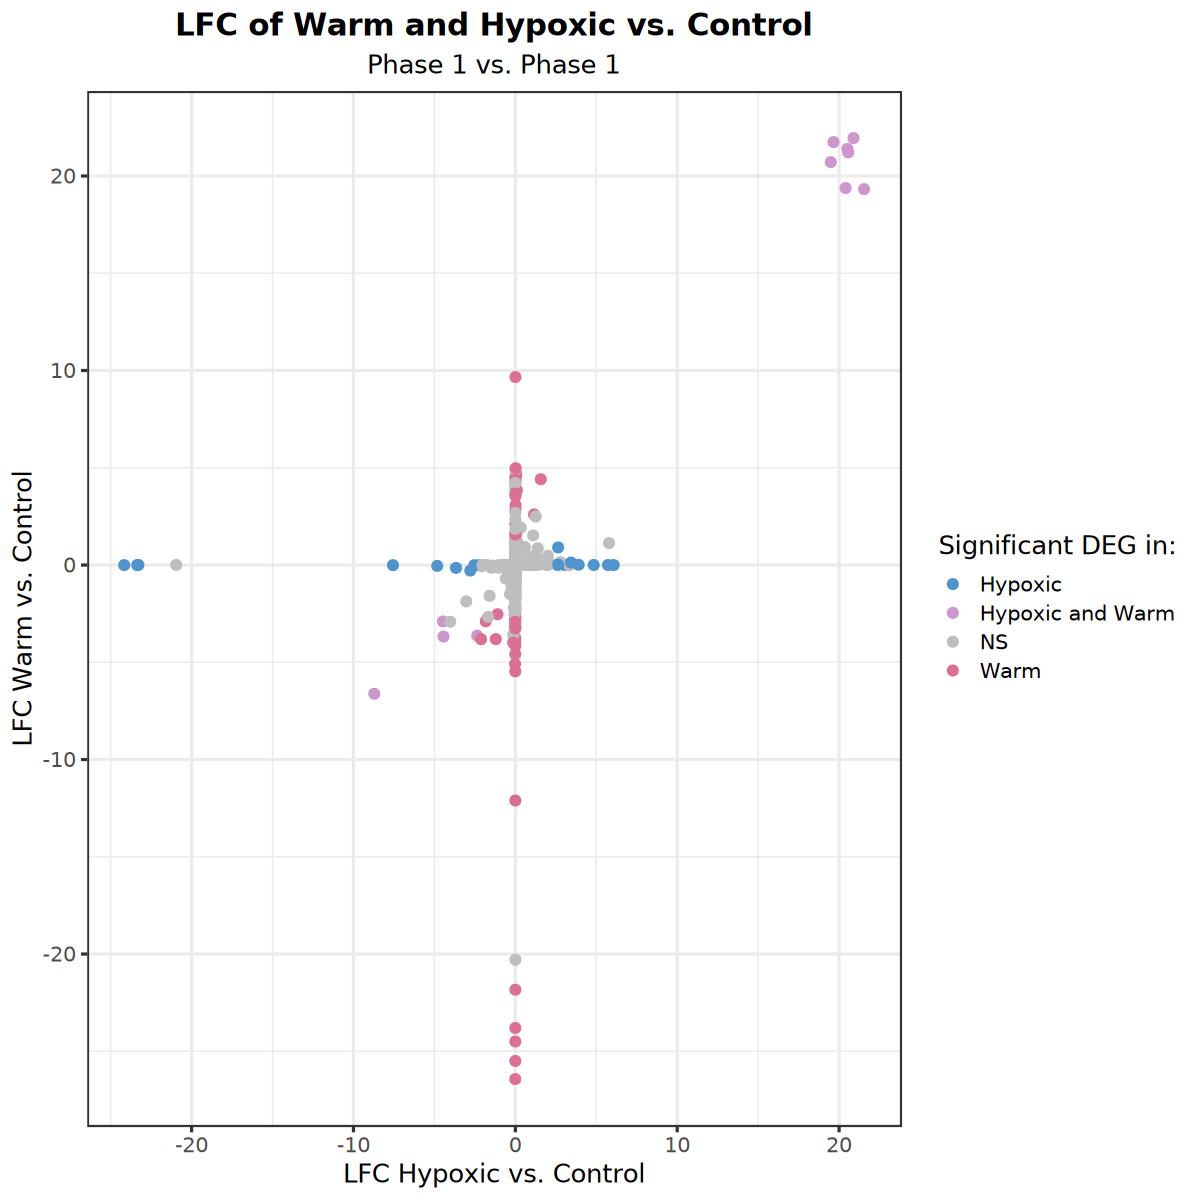

In [102]:
options(repr.plot.width=10, repr.plot.height=10)

ggplot(df_plot, aes(x=log2FC_h, y = log2FC_w, color = DEG_group_combined)) +
geom_point() + 
theme_bw(base_size = 15) +
scale_color_manual(values = c("Hypoxic" = "steelblue3", "Warm" = "palevioletred", "Hypoxic and Warm" = "plum3", "NS" = "grey")) +
labs(x = 'LFC Hypoxic vs. Control',
     y = 'LFC Warm vs. Control',
     color = 'Significant DEG in:',
    title = 'LFC of Warm and Hypoxic vs. Control',
    subtitle = 'Phase 1 vs. Phase 1') +
theme(plot.title = element_text(hjust = 0.5, face = 'bold'),
      plot.subtitle = element_text(hjust = 0.5))

observations:
- most DEGs are not shared for these comparisons (kinda already knew that)
- but if they are shared, they're mainly shared in the same direction (up-regulated in warm = up-regulated in hypoxia against control)